In [7]:
import pandas as pd

df = pd.read_csv("../dashboards/fact_performance.csv")

print(df.columns)

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='str')


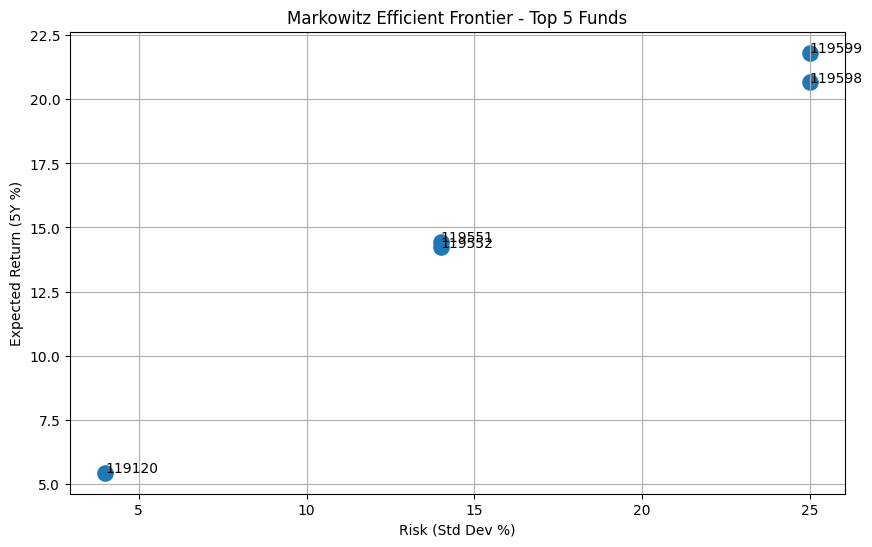

Efficient Frontier completed!


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("../dashboards/fact_performance.csv")

# Select first 5 funds
funds = df.head(5)

# Expected return
returns = funds["return_5yr_pct"]

# Risk
risks = funds["std_dev_ann_pct"]

# Plot Efficient Frontier
plt.figure(figsize=(10,6))

plt.scatter(
    risks,
    returns,
    s=120
)

for i, txt in enumerate(funds["amfi_code"]):
    plt.annotate(
        txt,
        (risks.iloc[i], returns.iloc[i])
    )

plt.xlabel("Risk (Std Dev %)")
plt.ylabel("Expected Return (5Y %)")
plt.title("Markowitz Efficient Frontier - Top 5 Funds")
plt.grid(True)

plt.savefig("efficient_frontier.png")
plt.show()

# Save results
funds[[
    "amfi_code",
    "return_5yr_pct",
    "std_dev_ann_pct",
    "sharpe_ratio"
]].to_csv(
    "efficient_frontier.csv",
    index=False
)

print("Efficient Frontier completed!")